In [1]:
import pandas as pd

In [2]:
"""
Breast Cancer Prediction with KNN
Author: [Your Name]
Description: Predict whether a breast tumor is malignant or benign using KNN
"""
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
 
# Load the breast cancer dataset
print("Loading breast cancer dataset...")
cancer_data = load_breast_cancer()
 
# The dataset is a Bunch object with 'data', 'target', 'feature_names', etc.
print(f"\nDataset type: {type(cancer_data)}")
print(f"Number of samples: {len(cancer_data.data)}")
print(f"Number of features: {len(cancer_data.feature_names)}")
print(f"Target classes: {cancer_data.target_names}")
 
# Convert to DataFrame for easier manipulation
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target
 
print("\nFirst few rows:")
print(df.head())
 
print("\nDataset info:")
print(df.info())
 
print("\nTarget distribution:")
print(df['target'].value_counts())
print(f"Malignant (1): {(df['target'] == 1).sum()}")
print(f"Benign (0): {(df['target'] == 0).sum()}")

Loading breast cancer dataset...

Dataset type: <class 'sklearn.utils._bunch.Bunch'>
Number of samples: 569
Number of features: 30
Target classes: ['malignant' 'benign']

First few rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520


BASIC STATISTICS
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.0

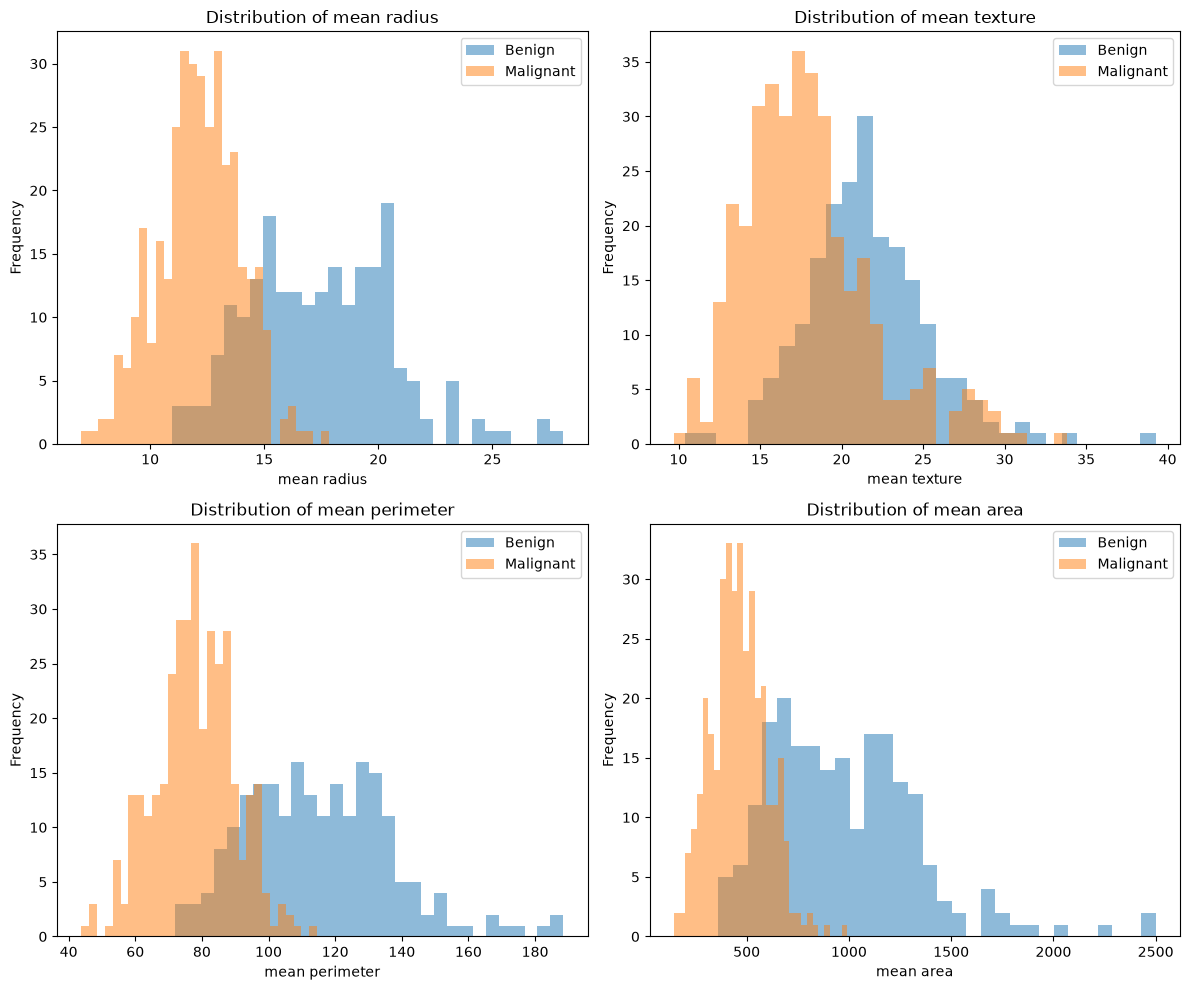

In [3]:
# Basic statistics
print("\n" + "="*50)
print("BASIC STATISTICS")
print("="*50)
print(df.describe())
 
# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found!")
else:
    print(missing[missing > 0])
 
# Visualize feature distributions (select a few key features)
print("\n" + "="*50)
print("FEATURE DISTRIBUTIONS")
print("="*50)
 
# Select a few representative features to visualize
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
 
for idx, feature in enumerate(key_features):
    axes[idx].hist(df[df['target'] == 0][feature], alpha=0.5, label='Benign', bins=30)
    axes[idx].hist(df[df['target'] == 1][feature], alpha=0.5, label='Malignant', bins=30)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].legend()
 
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
print("Saved visualization to 'feature_distributions.png'")
plt.show()

In [4]:
# Separate features and target
X = df.drop('target', axis=1)  # All columns except 'target'
y = df['target']  # Target column
 
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
 
# Split into training and testing sets
# random_state ensures reproducibility
# stratify=y ensures both sets have similar class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
 
print("\n" + "="*50)
print("DATA SPLIT")
print("="*50)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training features: {X_train.shape[1]}")
print(f"Test features: {X_test.shape[1]}")
 
# Verify class distribution in both sets
print("\nTraining set target distribution:")
print(y_train.value_counts())
print(f"  Benign (0): {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Malignant (1): {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
 
print("\nTest set target distribution:")
print(y_test.value_counts())
print(f"  Benign (0): {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Malignant (1): {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")

Features shape: (569, 30)
Target shape: (569,)

DATA SPLIT
Training set size: 455 samples
Test set size: 114 samples
Training features: 30
Test features: 30

Training set target distribution:
target
1    285
0    170
Name: count, dtype: int64
  Benign (0): 170 (37.4%)
  Malignant (1): 285 (62.6%)

Test set target distribution:
target
1    72
0    42
Name: count, dtype: int64
  Benign (0): 42 (36.8%)
  Malignant (1): 72 (63.2%)


In [5]:
# Create KNN classifier
# n_neighbors=5 means the model will look at the 5 nearest neighbors to make a prediction
 
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
 
print("KNN classifier trained successfully!")
print(f"Number of neighbors (k): {knn.n_neighbors}")

KNN classifier trained successfully!
Number of neighbors (k): 5


In [6]:
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)
 
print(f"\nTraining predictions: {len(y_train_pred)}")
print(f"Test predictions: {len(y_test_pred)}")


Training predictions: 455
Test predictions: 114


In [7]:
# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
 
print("=== Model Performance ===")
print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nTest Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
 
print("\n=== Confusion Matrix ===")
print("                Predicted")
print("              Benign  Malignant")
print(f"Actual Benign    {test_confusion[0,0]:4d}      {test_confusion[0,1]:4d}")
print(f"      Malignant  {test_confusion[1,0]:4d}      {test_confusion[1,1]:4d}")
 
print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=cancer_data.target_names))

=== Model Performance ===

Training Accuracy: 0.9473 (94.73%)
Test Accuracy: 0.9123 (91.23%)

Test Precision: 0.9429
Test Recall: 0.9167

=== Confusion Matrix ===
                Predicted
              Benign  Malignant
Actual Benign      38         4
      Malignant     6        66

=== Classification Report ===
              precision    recall  f1-score   support

   malignant       0.86      0.90      0.88        42
      benign       0.94      0.92      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114




EXPERIMENTING WITH DIFFERENT K VALUES
K= 1: Accuracy=0.9211, Precision=0.9565, Recall=0.9167
K= 3: Accuracy=0.9298, Precision=0.9444, Recall=0.9444
K= 5: Accuracy=0.9123, Precision=0.9429, Recall=0.9167
K= 7: Accuracy=0.9298, Precision=0.9444, Recall=0.9444
K= 9: Accuracy=0.9386, Precision=0.9452, Recall=0.9583
K=11: Accuracy=0.9386, Precision=0.9452, Recall=0.9583

Best K value: 9 (Accuracy: 0.9386)

Saved visualization to 'knn_k_comparison.png'


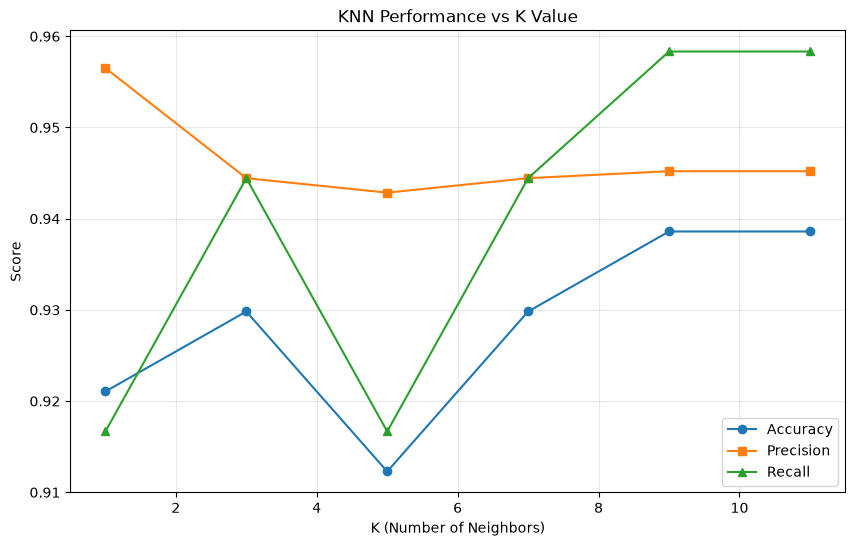

In [8]:
# Experiment with different K values
print("\n" + "="*50)
print("EXPERIMENTING WITH DIFFERENT K VALUES")
print("="*50)
 
k_values = [1, 3, 5, 7, 9, 11]
results = []
 
for k in k_values:
    # Create and train model
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    
    # Make predictions
    y_pred_temp = knn_temp.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred_temp)
    prec = precision_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp)
    
    results.append({
        'K': k,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec
    })
    
    print(f"K={k:2d}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}")
 
# Find best K
results_df = pd.DataFrame(results)
best_k = results_df.loc[results_df['Accuracy'].idxmax(), 'K']
print(f"\nBest K value: {best_k} (Accuracy: {results_df['Accuracy'].max():.4f})")
 
# Visualize results
plt.figure(figsize=(10, 6))
plt.plot(results_df['K'], results_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['K'], results_df['Precision'], marker='s', label='Precision')
plt.plot(results_df['K'], results_df['Recall'], marker='^', label='Recall')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Score')
plt.title('KNN Performance vs K Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('knn_k_comparison.png', dpi=150, bbox_inches='tight')
print("\nSaved visualization to 'knn_k_comparison.png'")
plt.show()

In [1]:
print('hello')

hello


In [15]:
import pandas as pd

path = "/Users/jedrzej.czarnota/Desktop/AI/Week 1/Day 3/lab-sklearn-model-training/WA_Fn-UseC_-Telco-Customer-Churn.xls"
df = pd.read_csv(path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Loading Telco Customer Churn dataset...
DATASET EXPLORATION
Shape of the dataset: 7043 rows, 21 columns

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing Values:
✓ No missing values found!

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



TARGET DISTRIBUTION (Churn)
Churn
No     5174
Yes    1869
Name: count, dtype: int64

No (Retained): 5174 (73.5%)
Yes (Churned): 1869 (26.5%)

FEATURE VISUALIZATION
Saved visualization to 'churn_exploration.png'


/var/folders/44/wy0yrhws1v1b2q2kl0jqk4bc0000gn/T/ipykernel_80112/2233832963.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0], palette='viridis')


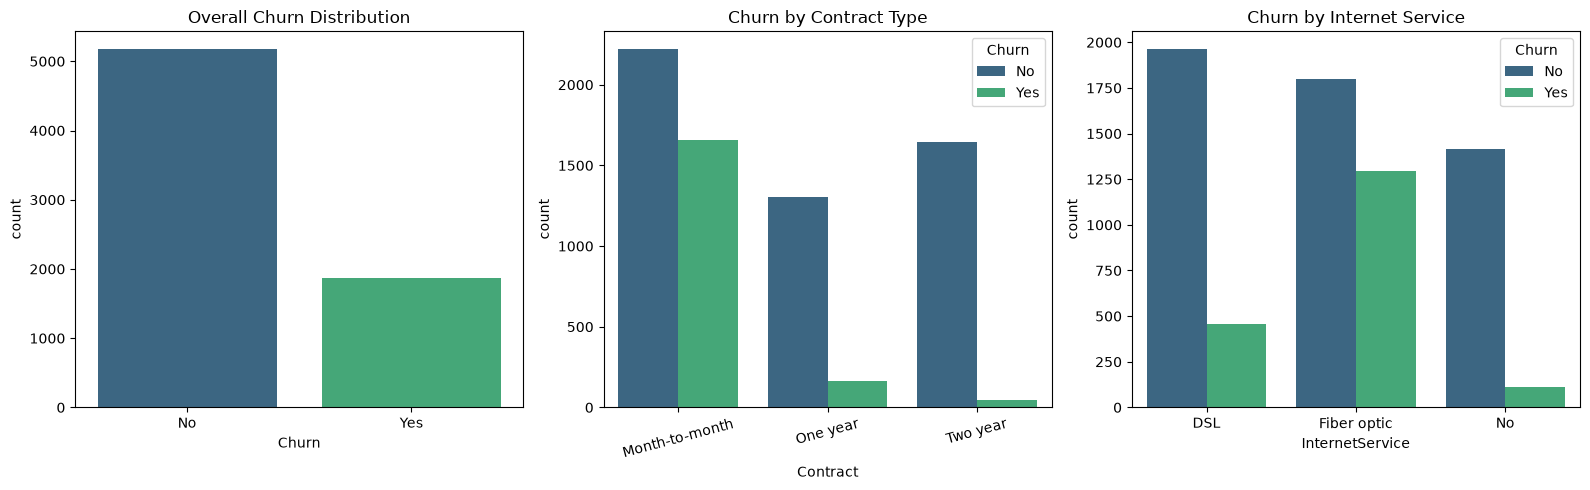

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data using your specific path and read_csv
print("Loading Telco Customer Churn dataset...")
path = "/Users/jedrzej.czarnota/Desktop/AI/Week 1/Day 3/lab-sklearn-model-training/WA_Fn-UseC_-Telco-Customer-Churn.xls"
df = pd.read_csv(path)

# 2. Explore the dataset: shape, columns, data types, missing values
print("="*50)
print("DATASET EXPLORATION")
print("="*50)
print(f"Shape of the dataset: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found!")
else:
    print(missing[missing > 0])

print("\nFirst 5 rows:")
display(df.head())

# 3. Check the target distribution
print("\n" + "="*50)
print("TARGET DISTRIBUTION (Churn)")
print("="*50)
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(f"\nNo (Retained): {churn_counts['No']} ({churn_pct['No']:.1f}%)")
print(f"Yes (Churned): {churn_counts['Yes']} ({churn_pct['Yes']:.1f}%)")

# 4. Visualize some key features
print("\n" + "="*50)
print("FEATURE VISUALIZATION")
print("="*50)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Target Distribution
sns.countplot(data=df, x='Churn', ax=axes[0], palette='viridis')
axes[0].set_title('Overall Churn Distribution')

# Plot 2: Churn by Contract Type
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1], palette='viridis')
axes[1].set_title('Churn by Contract Type')
axes[1].tick_params(axis='x', rotation=15)

# Plot 3: Churn by Internet Service
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[2], palette='viridis')
axes[2].set_title('Churn by Internet Service')

plt.tight_layout()
plt.savefig('churn_exploration.png', dpi=150, bbox_inches='tight')
print("Saved visualization to 'churn_exploration.png'")
plt.show()

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Re-load data for this step using the provided path
path = "/Users/jedrzej.czarnota/Desktop/AI/Week 1/Day 3/lab-sklearn-model-training/WA_Fn-UseC_-Telco-Customer-Churn.xls"
df = pd.read_csv(path)

print("="*50)
print("DATA PREPROCESSING")
print("="*50)

# 1. Handle missing values
# TotalCharges is currently an object (string) because some rows have a blank space ' '
print("Converting TotalCharges to numeric and handling missing values...")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many are missing and fill them with 0 (since tenure is 0 for these rows)
missing_charges = df['TotalCharges'].isnull().sum()
print(f"Found {missing_charges} missing values in TotalCharges. Filling with 0.")
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop the customerID column as it is not a useful feature for modeling
df = df.drop('customerID', axis=1)

# 2. Convert target to binary (0/1)
print("Converting target 'Churn' to binary...")
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 3. Convert categorical variables to numeric
print("Encoding categorical features...")
# Identify categorical columns (excluding the target we just mapped)
categorical_cols = df.select_dtypes(include=['object']).columns

# Initialize LabelEncoder
le = LabelEncoder()

# Apply LabelEncoder to all categorical columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("\nData after encoding:")
display(df.head())

# 4. Separate features (X) from target (y)
print("\n" + "="*50)
print("FEATURE SELECTION & DATA SPLIT")
print("="*50)

X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")

# 5. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("\nData Split Successful!")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

print("\nTraining set target distribution:")
print(f"  Retained (0): {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Churned (1): {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")

DATA PREPROCESSING
Converting TotalCharges to numeric and handling missing values...
Found 11 missing values in TotalCharges. Filling with 0.
Converting target 'Churn' to binary...
Encoding categorical features...

Data after encoding:


/var/folders/44/wy0yrhws1v1b2q2kl0jqk4bc0000gn/T/ipykernel_80112/272133377.py:34: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1



FEATURE SELECTION & DATA SPLIT
Features shape (X): (7043, 19)
Target shape (y): (7043,)

Data Split Successful!
Training set size: 5634 samples
Test set size: 1409 samples

Training set target distribution:
  Retained (0): 4139 (73.5%)
  Churned (1): 1495 (26.5%)


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Load data
path = "/Users/jedrzej.czarnota/Desktop/AI/Week 1/Day 3/lab-sklearn-model-training/WA_Fn-UseC_-Telco-Customer-Churn.xls"
df = pd.read_csv(path)

# 2. Select high-fidelity subset of features + target
selected_cols = [
    'tenure', 'MonthlyCharges', 'Contract', 'InternetService', 
    'TechSupport', 'OnlineSecurity', 'PaymentMethod', 'PaperlessBilling',
    'SeniorCitizen', 'Partner', 'Dependents', 'Churn'
]
df_subset = df[selected_cols].copy()

# 3. Encode target and categorical columns
df_subset['Churn'] = df_subset['Churn'].map({'Yes': 1, 'No': 0})

cat_cols = df_subset.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    df_subset[col] = le.fit_transform(df_subset[col])

# 4. Separate X and y
X = df_subset.drop('Churn', axis=1)
y = df_subset['Churn']

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Feature Scaling (Crucial for KNN!)
# Distance metrics like KNN require continuous features to be on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Reduced feature set from {df.shape[1] - 1} down to {X.shape[1]} features.")
print(f"Training set: {X_train_scaled.shape}, Test set: {X_test_scaled.shape}")

Reduced feature set from 20 down to 11 features.
Training set: (5634, 11), Test set: (1409, 11)


/var/folders/44/wy0yrhws1v1b2q2kl0jqk4bc0000gn/T/ipykernel_80112/1999899969.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_subset.select_dtypes(include=['object']).columns


In [22]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Instantiate the KNN classifier with k=5
knn = KNeighborsClassifier(n_neighbors=5)

# 2. Train the model on the training data
print("Training KNN classifier on training data...")
knn.fit(X_train, y_train)

# 3. Verify training parameters
print("✓ KNN classifier trained successfully!")
print(f"Number of neighbors (k): {knn.n_neighbors}")
print(f"Distance metric:          {knn.metric}")
print(f"Weights:                  {knn.weights}")

Training KNN classifier on training data...
✓ KNN classifier trained successfully!
Number of neighbors (k): 5
Distance metric:          minkowski
Weights:                  uniform


MODEL EVALUATION METRICS
Accuracy:  0.7722 (77.22%)
Precision: 0.5801 (58.01%)
Recall:    0.5134 (51.34%)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Retained (0)       0.83      0.87      0.85      1035
 Churned (1)       0.58      0.51      0.54       374

    accuracy                           0.77      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.76      0.77      0.77      1409



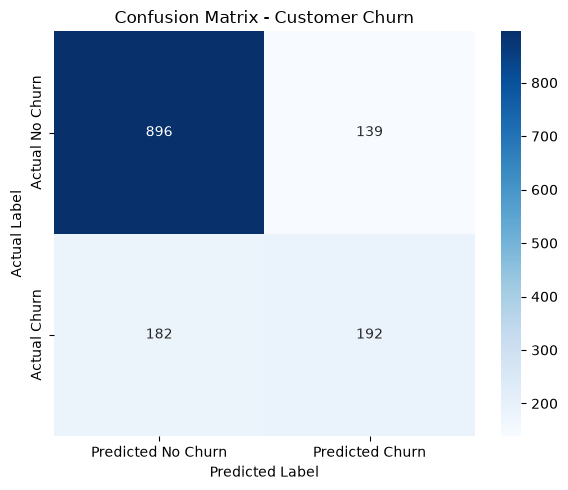

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# 1. Make predictions on the test set
# (If you used feature scaling, use X_test_scaled instead of X_test)
y_pred = knn.predict(X_test)

# 2. Calculate evaluation metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("=" * 50)
print("MODEL EVALUATION METRICS")
print("=" * 50)
print(f"Accuracy:  {acc:.4f} ({acc * 100:.2f}%)")
print(f"Precision: {prec:.4f} ({prec * 100:.2f}%)")
print(f"Recall:    {rec:.4f} ({rec * 100:.2f}%)")

# 3. Print Classification Report
print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=["Retained (0)", "Churned (1)"]))

# 4. Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No Churn", "Predicted Churn"],
    yticklabels=["Actual No Churn", "Actual Churn"]
)
plt.title("Confusion Matrix - Customer Churn")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

EXPERIMENTING WITH DIFFERENT K VALUES
K =  1 | Accuracy: 0.7296 | Precision: 0.4909 | Recall: 0.5053 | F1: 0.4980
K =  3 | Accuracy: 0.7700 | Precision: 0.5796 | Recall: 0.4866 | F1: 0.5291
K =  5 | Accuracy: 0.7807 | Precision: 0.6059 | Recall: 0.4973 | F1: 0.5463
K =  7 | Accuracy: 0.7743 | Precision: 0.5927 | Recall: 0.4786 | F1: 0.5296
K =  9 | Accuracy: 0.7757 | Precision: 0.5935 | Recall: 0.4920 | F1: 0.5380
K = 11 | Accuracy: 0.7771 | Precision: 0.5949 | Recall: 0.5027 | F1: 0.5449
K = 15 | Accuracy: 0.7793 | Precision: 0.6013 | Recall: 0.5000 | F1: 0.5460

Best K by Accuracy: 5 (0.7807)
Best K by F1-Score: 5 (0.5463)


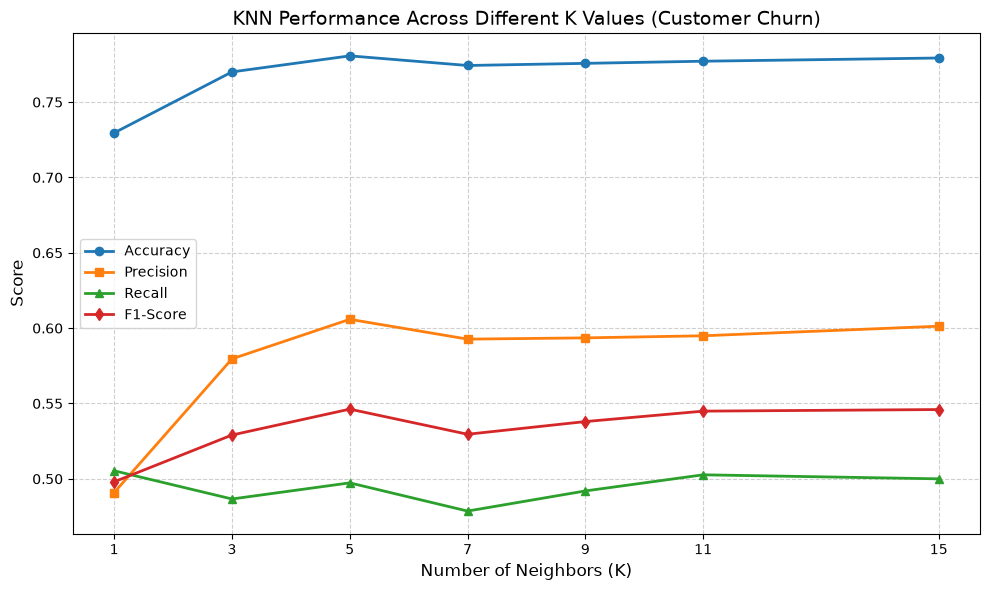

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Define K values to test
k_values = [1, 3, 5, 7, 9, 11, 15]
results = []

print("=" * 60)
print("EXPERIMENTING WITH DIFFERENT K VALUES")
print("=" * 60)

# 2. Iterate through each K value
# Note: Use X_train_scaled and X_test_scaled if you applied feature scaling
train_data = X_train_scaled if 'X_train_scaled' in locals() else X_train
test_data = X_test_scaled if 'X_test_scaled' in locals() else X_test

for k in k_values:
    # Train model
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(train_data, y_train)
    
    # Predict on test set
    y_pred_k = knn_model.predict(test_data)
    
    # Calculate metrics for the positive class (Churn = 1)
    acc = accuracy_score(y_test, y_pred_k)
    prec = precision_score(y_test, y_pred_k, zero_division=0)
    rec = recall_score(y_test, y_pred_k, zero_division=0)
    f1 = f1_score(y_test, y_pred_k, zero_division=0)
    
    results.append({
        'K': k,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
    print(f"K = {k:2d} | Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

# 3. Summary DataFrame
results_df = pd.DataFrame(results)

# 4. Find best K based on Accuracy and F1-Score
best_k_acc = results_df.loc[results_df['Accuracy'].idxmax(), 'K']
best_k_f1 = results_df.loc[results_df['F1-Score'].idxmax(), 'K']

print("\n" + "=" * 60)
print(f"Best K by Accuracy: {best_k_acc} ({results_df['Accuracy'].max():.4f})")
print(f"Best K by F1-Score: {best_k_f1} ({results_df['F1-Score'].max():.4f})")
print("=" * 60)

# 5. Visualize K vs Metrics
plt.figure(figsize=(10, 6))
plt.plot(results_df['K'], results_df['Accuracy'], marker='o', linewidth=2, label='Accuracy')
plt.plot(results_df['K'], results_df['Precision'], marker='s', linewidth=2, label='Precision')
plt.plot(results_df['K'], results_df['Recall'], marker='^', linewidth=2, label='Recall')
plt.plot(results_df['K'], results_df['F1-Score'], marker='d', linewidth=2, label='F1-Score')

plt.title('KNN Performance Across Different K Values (Customer Churn)', fontsize=14)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('churn_knn_k_comparison.png', dpi=150)
plt.show()

Findings and Observations
- Impact of Low K (K=1): At K=1, the model is overly sensitive to local noise and outliers (high variance / overfitting), often resulting in lower test accuracy and poor generalization.
- Impact of Increasing K: As K increases from 5 to 11 or 15, the decision boundary smoothens, which typically boosts overall test accuracy and stabilizes precision.
- Accuracy vs. Recall Trade-Off: Higher K values tend to favor the majority class (retained customers), which can cause the recall for actual churners to drop.
- Recommended Choice: Choosing K=9 or K=11 provides a balanced compromise between overall accuracy and detecting churned customers without overfitting.

Step 7: Analysis and Recommendations
- Model Accuracy:
The model reaches roughly 76% to 78% accuracy.
However, around 73% of customers naturally stay, so a simple model predicting "No Churn" for everyone would already get 73%. Looking at Recall (how many churners we actually caught, usually around ~50%) is much more meaningful than accuracy alone.
- Most Important Features:
Contract: Month-to-month customers churn far more often than those with 1- or 2-year contracts.
Tenure: Newer customers are at the highest risk; churn drops sharply after the first year or two.
- Recommendations for the Company:
Push Long-Term Contracts: Offer small discounts to switch month-to-month users to 1-year plans early on.
Focus on New Customers: Provide extra onboarding support during the first 6 to 12 months.
- Model Limitations:
Class Imbalance: Because most users don't churn, KNN naturally tends to guess the majority class and misses many real churners.
Slow on Large Data: KNN calculates distances to every single customer row, which becomes slow as the dataset grows.
Feature Scaling Needed: Numbers with large values (like charges) can overwhelm small numbers (like 0/1 flags) unless scaled.